In [1]:
#02_modeling.ipynb
#
#by Joe Hahn
#jmh.datasciences@gmail.com
#4 August 2026
#
#train two models to predict which customers buy the tax software

In [2]:
#start time
import time as tm
clock_start = tm.time()

In [3]:
#import python libraries
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)
import warnings
warnings.filterwarnings('ignore')
print('pandas = ', pd.__version__)

pandas =  3.0.5


In [4]:
#import plotting libraries
#use following line when in Jupyter
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')

In [5]:
#input parameters
train_file = 'train.parquet'
test_file = 'test.parquet'
y_col = 'target'
model_file = 'models.joblib'
rn_seed = 14
cv_folds = 5          #cross-validation (CV) folds: train on 4/5 of the training data,
                      #score the held-out 1/5, rotate. tunes without touching test.parquet
print('train_file      = ', train_file)
print('test_file       = ', test_file)
print('model_file      = ', model_file)
print('rn_seed         = ', rn_seed)
print('cv_folds        = ', cv_folds)

train_file      =  train.parquet
test_file       =  test.parquet
model_file      =  models.joblib
rn_seed         =  14
cv_folds        =  5


In [6]:
#read the test/train samples generted by notebook 1
train = pd.read_parquet(train_file)
test = pd.read_parquet(test_file)
print('train.shape = ', train.shape, '  sell rate = ', round(train[y_col].mean(), 4))
print('test.shape  = ', test.shape, '  sell rate = ', round(test[y_col].mean(), 4))
print('nulls       = ', train.isna().sum().sum(), ' (notebook 1 encoded them all as -1)')
train.head()

train.shape =  (30891, 24)   sell rate =  0.1127
test.shape  =  (10297, 24)   sell rate =  0.1127
nulls       =  0  (notebook 1 encoded them all as -1)


,age,employment,marriage_status,school,has_housing_loan*,has_personal_loan*,credit_in_default*,contact_channel*,month,dow,contacts_this_campaign*,days_since_prior_contact*,prior_contact_count*,prior_campaign_outcome*,never_contacted_before,is_repeat_contact,emp_variation_rate*,consumer_price_index*,consumer_confidence_index*,euribor_3m*,n_employed*,unknown_n3,unknown_n5,target
27851,36,assistant,married,5 - a decent amount,yes,yes,no,new,may,fri,1,-1.0,0,-1,1,0,-1.8,92.893,-46.2,1.259,5099.1,710,-1.606045,0
10560,33,assistant,married,5 - a lot,no,yes,no,new,sep,wed,1,-1.0,2,no,1,0,-1.1,94.199,-37.5,0.879,4963.6,660,-0.067963,1
32752,59,laborer,married,3 - a bit more,no,no,no,new,apr,thu,2,-1.0,1,no,1,1,-1.8,93.075,-47.1,1.410,5099.1,780,-1.070524,0
15442,54,assistant,married,1 - almost none,yes,no,-1,new,nov,tue,4,-1.0,0,-1,1,1,-0.1,93.200,-42.0,4.153,5195.8,990,-1.414095,0
25557,58,management,married,5 - a lot,yes,no,no,new,may,thu,2,-1.0,0,-1,1,1,-1.8,93.876,-40.0,0.692,5008.7,860,0.468118,1


In [7]:
#split into features and target, and sort the columns by type
x_cols = [c for c in train.columns if c != y_col]
cat_cols = train[x_cols].select_dtypes(exclude='number').columns.tolist()
num_cols = train[x_cols].select_dtypes(include='number').columns.tolist()
x_train, y_train = train[x_cols], train[y_col]
x_test, y_test = test[x_cols], test[y_col]
print('N_categorical = ', len(cat_cols), '  ', cat_cols)
print()
print('N_numeric     = ', len(num_cols), '  ', num_cols)

N_categorical =  10    ['employment', 'marriage_status', 'school', 'has_housing_loan*', 'has_personal_loan*', 'credit_in_default*', 'contact_channel*', 'month', 'dow', 'prior_campaign_outcome*']

N_numeric     =  13    ['age', 'contacts_this_campaign*', 'days_since_prior_contact*', 'prior_contact_count*', 'never_contacted_before', 'is_repeat_contact', 'emp_variation_rate*', 'consumer_price_index*', 'consumer_confidence_index*', 'euribor_3m*', 'n_employed*', 'unknown_n3', 'unknown_n5']


## 1. preprocessing

In [8]:
#trees and linear models need different prep, so build a preprocessor for each
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

sentinel_col = 'days_since_prior_contact*'
other_num = [c for c in num_cols if c not in ('age', sentinel_col)]

#age: the sell rate is U-shaped, so age-buckets let the linear model bend with age
age_bins = [16, 25, 30, 40, 50, 60, 70, 100]
age_binner = Pipeline([('bin', FunctionTransformer(np.digitize, kw_args={'bins': age_bins},
                                                   feature_names_out='one-to-one')),
                       ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                sparse_output=False))])

#one-hot, pooling rare levels and unseen categories into one 'infrequent' column...only
#credit_in_default*='yes' (3 rows) and school='0 - none' (14) are rare. dense for the tree
onehot = OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=20, sparse_output=False)

#days_since_prior_contact*: -1 means never contacted, and a linear model would read that
#as a negative duration, so impute to the median and let never_contacted_before say it
sentinel_prep = Pipeline([('impute', SimpleImputer(missing_values=-1, strategy='median')),
                          ('scale', StandardScaler())])

#everything else numeric is standardised to mean 0, sd 1
prep_linear = ColumnTransformer([
    ('cat', onehot, cat_cols),
    ('age', age_binner, ['age']),
    ('sentinel', sentinel_prep, [sentinel_col]),
    ('num', StandardScaler(), other_num)])

#the tree needs none of it: no scaling, and -1 is just another value to split on
prep_tree = ColumnTransformer([
    ('cat', onehot, cat_cols),
    ('num', 'passthrough', num_cols)])
print('prep_linear and prep_tree built')

prep_linear and prep_tree built


In [9]:
#everything goes in a Pipeline so the encoder, scaler and imputer refit inside each cross-validation 
#fold.
xt = prep_linear.fit_transform(x_train)
print('linear prep: ', x_train.shape[1], ' columns in -> ', xt.shape[1], ' out')
xt = prep_tree.fit_transform(x_train)
print('tree prep  : ', x_train.shape[1], ' columns in -> ', xt.shape[1], ' out')
print()
print('sample of the one-hot names the linear prep produces:')
print(list(prep_linear.get_feature_names_out()[:8]))

linear prep:  23  columns in ->  72  out
tree prep  :  23  columns in ->  66  out

sample of the one-hot names the linear prep produces:
['cat__employment_-1', 'cat__employment_assistant', 'cat__employment_cleaner', 'cat__employment_customer service', 'cat__employment_engineer', 'cat__employment_hobbyist', 'cat__employment_laborer', 'cat__employment_leisure']


## 2. two models, out of the box

In [10]:
#logistic regression and gradient-boosted trees: deliberately different families,
#fit untuned to see where we start. the three scores below:
#  roc_auc: area under a plot of true positive rate vs false positive rate, swept over
#           roc_auc=0.5 (coin flip) while 1.0 = perfect model
#  pr_auc:  area under a plot of precision vs recall, both axes count only the buyers, 
#           so the 89% of easy non-buyers do not flatter the model. 
#           a random model scores the base rate, 0.113
#  brier:   mean squared error of the probabilities, lower is better.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

pipe_lr = Pipeline([('prep', prep_linear),
                    ('model', LogisticRegression(max_iter=5000, random_state=rn_seed))])
pipe_lr.fit(x_train, y_train)
prob_lr = pipe_lr.predict_proba(x_test)[:, 1]

pipe_gb = Pipeline([('prep', prep_tree),
                    ('model', HistGradientBoostingClassifier(random_state=rn_seed))])
pipe_gb.fit(x_train, y_train)
prob_gb = pipe_gb.predict_proba(x_test)[:, 1]

base_scores = pd.DataFrame([
    {'model': 'logistic', 'roc_auc': roc_auc_score(y_test, prob_lr),
     'pr_auc': average_precision_score(y_test, prob_lr),
     'brier': brier_score_loss(y_test, prob_lr), 'mean_prob': prob_lr.mean()},
    {'model': 'gradient boosting', 'roc_auc': roc_auc_score(y_test, prob_gb),
     'pr_auc': average_precision_score(y_test, prob_gb),
     'brier': brier_score_loss(y_test, prob_gb), 'mean_prob': prob_gb.mean()},
])
print('actual sell rate = ', round(y_test.mean(), 4))
base_scores.round(4)

actual sell rate =  0.1127


,model,roc_auc,pr_auc,brier,mean_prob
0,logistic,0.7881,0.4566,0.0782,0.1130
1,gradient boosting,0.8036,0.4763,0.0765,0.1134


In [11]:
#rebalancing is the usual treatment for no:yes=8:1, but rebalancing did not improve 
#roc_auc and it worsens brier and also alters mean_prob, so we skip it
weight_rows = []
for label, weight in [('class_weight=None', None), ("class_weight='balanced'", 'balanced')]:
    pipe = Pipeline([('prep', prep_linear),
                     ('model', LogisticRegression(max_iter=5000, class_weight=weight,
                                                  random_state=rn_seed))]).fit(x_train, y_train)
    pr = pipe.predict_proba(x_test)[:, 1]
    weight_rows.append({'model': label, 'roc_auc': roc_auc_score(y_test, pr),
                        'pr_auc': average_precision_score(y_test, pr),
                        'brier': brier_score_loss(y_test, pr), 'mean_prob': pr.mean()})
print('actual sell rate = ', round(y_test.mean(), 4), ', so mean_prob should land near it')
pd.DataFrame(weight_rows).round(4)

actual sell rate =  0.1127 , so mean_prob should land near it


,model,roc_auc,pr_auc,brier,mean_prob
0,class_weight=None,0.7881,0.4566,0.0782,0.1130
1,class_weight='balanced',0.7891,0.4497,0.1642,0.3889


## 3. tuning

every hyperparameter searched below is a dial between *fit the training data harder* and
*generalise better*, ie between underfitting and overfitting:

- `model__C` (logistic) — inverse penalty on coefficient size. small C shrinks the
  coefficients toward zero and simplifies the model, large C lets it chase the training data
- `model__learning_rate` — how far each new tree corrects the ones before it. small means
  slow careful steps, which usually generalise better
- `model__max_leaf_nodes` — how many splits a tree may make, ie its size, and how complex
  an interaction it can represent
- `model__min_samples_leaf` — fewest customers allowed in a leaf, which stops the model
  carving out tiny groups that are really noise
- `model__l2_regularization` — pulls each leaf's prediction back toward the overall average

the search tries combinations of these and keeps whichever scores best in cross-validation.

In [12]:
#tune with successive halving rather than a full grid: it starts many candidates on a
#small slice of the data, keeps the best third, and triples their budget. scoring is roc_auc
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=rn_seed)
grids = {
    'logistic': (prep_linear, LogisticRegression(max_iter=5000, random_state=rn_seed),
                 {'model__C': np.logspace(-3, 1, 20)}),
    'gradient boosting': (prep_tree, HistGradientBoostingClassifier(random_state=rn_seed),
                          {'model__learning_rate': np.logspace(-2, -0.5, 12),
                           'model__max_leaf_nodes': [7, 15, 31, 63],
                           'model__min_samples_leaf': [10, 20, 50, 100, 200],
                           'model__l2_regularization': np.logspace(-3, 1, 10)}),
}
tuned, tuned_prob = {}, {}
for name, (prep, model, grid) in grids.items():
    t0 = tm.time()
    search = HalvingRandomSearchCV(Pipeline([('prep', prep), ('model', model)]), grid,
                                   scoring='roc_auc', cv=cv, factor=3, resource='n_samples',
                                   n_candidates=120, min_resources=3000,
                                   random_state=rn_seed, n_jobs=-1, refit=True).fit(x_train, y_train)
    tuned[name] = search
    tuned_prob[name] = search.best_estimator_.predict_proba(x_test)[:, 1]
    print(name)
    print('   ', len(search.cv_results_['params']), ' candidate fits in ',
          round(tm.time() - t0), 's   (summed over the halving rounds)')
    print('    best cv roc_auc = ', round(search.best_score_, 4))
    print('    best params     = ', search.best_params_)
    print()

logistic
    30  candidate fits in  3 s   (summed over the halving rounds)
    best cv roc_auc =  0.7917
    best params     =  {'model__C': np.float64(0.07847599703514611)}

gradient boosting
    174  candidate fits in  34 s   (summed over the halving rounds)
    best cv roc_auc =  0.7983
    best params     =  {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 15, 'model__learning_rate': np.float64(0.025650209056800457), 'model__l2_regularization': np.float64(3.593813663804626)}



In [13]:
#so what did the tuning actually buy? almost nothing, and for the tree it is negative:
#the search picked on cv score and this particular test split disagreed. that swing is
#inside the +/-0.005 that simply changing the train/test seed produces.
gain = pd.DataFrame([
    {'model': 'logistic', 'out_of_the_box': base_scores.roc_auc[0],
     'after_tuning': roc_auc_score(y_test, tuned_prob['logistic'])},
    {'model': 'gradient boosting', 'out_of_the_box': base_scores.roc_auc[1],
     'after_tuning': roc_auc_score(y_test, tuned_prob['gradient boosting'])},
])
gain['gain'] = gain.after_tuning - gain.out_of_the_box
gain.round(4)

,model,out_of_the_box,after_tuning,gain
0,logistic,0.7881,0.7883,0.0002
1,gradient boosting,0.8036,0.7990,-0.0046


## 4. model metrics

In [14]:
#the full picture, plus a baseline that says no to every customer. it is 88.7% accurate
#and sells nothing, which is why accuracy is not the measure here
from sklearn.metrics import precision_score, recall_score, f1_score

prob = {'logistic': tuned_prob['logistic'], 'gradient boosting': tuned_prob['gradient boosting']}
rows = []
for name, pr in prob.items():
    pred = (pr >= 0.5).astype(int)
    rows.append({'model': name,
                 'roc_auc': roc_auc_score(y_test, pr),
                 'pr_auc': average_precision_score(y_test, pr),
                 'brier': brier_score_loss(y_test, pr),
                 'precision': precision_score(y_test, pred, zero_division=0),
                 'recall': recall_score(y_test, pred, zero_division=0),
                 'f1': f1_score(y_test, pred, zero_division=0),
                 'accuracy': (pred == y_test).mean()})
metrics = pd.DataFrame(rows)
always_no = np.zeros(len(y_test))
baseline = pd.DataFrame([{'model': 'baseline: always says no',
                          'roc_auc': roc_auc_score(y_test, always_no),
                          'pr_auc': average_precision_score(y_test, always_no),
                          'brier': brier_score_loss(y_test, always_no),
                          'precision': np.nan, 'recall': 0.0, 'f1': 0.0,
                          'accuracy': (always_no == y_test).mean()}])
metrics = pd.concat([metrics, baseline], ignore_index=True)
print('the 0.5 cutoff behind precision/recall has no business meaning...notebook 4 replaces')
print('it with one derived from the cost of a call and the margin on a sale')
metrics.round(4)

the 0.5 cutoff behind precision/recall has no business meaning...notebook 4 replaces
it with one derived from the cost of a call and the margin on a sale


,model,roc_auc,pr_auc,brier,precision,recall,f1,accuracy
0,logistic,0.7883,0.4539,0.0784,0.6650,0.2276,0.3391,0.9001
1,gradient boosting,0.7990,0.4775,0.0768,0.7066,0.1931,0.3033,0.9001
2,baseline: always says no,0.5000,0.1127,0.1127,NaN,0.0000,0.0000,0.8873


the four right-hand columns all depend on a 0.5 cutoff, which has no business meaning
here...notebook 4 replaces it with one derived from the cost of a call and the margin on
a sale. cutting at 0.5 sorts every customer into four boxes:

- **TP** = number of buyers correctly predicted to buy
- **FP** = number of non-buyers wrongly predicted to buy
- **FN** = number of buyers wrongly predicted not to buy
- **TN** = number of non-buyers correctly predicted not to buy

- `precision` = TP / (TP + FP) — of everyone we predicted would buy, the fraction who did
- `recall` = TP / (TP + FN) — of everyone who actually bought, the fraction we caught
- `f1` = 2TP / (2TP + FP + FN) — the two combined, a compromise rather than a target
- `accuracy` = (TP + TN) / all — useless here, since the 9,137 non-buyers make TN huge and
  saying "no" to everyone already scores 88.7%

for gradient boosting above: TP=224, FP=93, FN=936, TN=9,044, so precision = 224/317 =
0.71 and recall = 224/1,160 = 0.19. raising the cutoff buys precision at the cost of
recall, lowering it does the reverse.

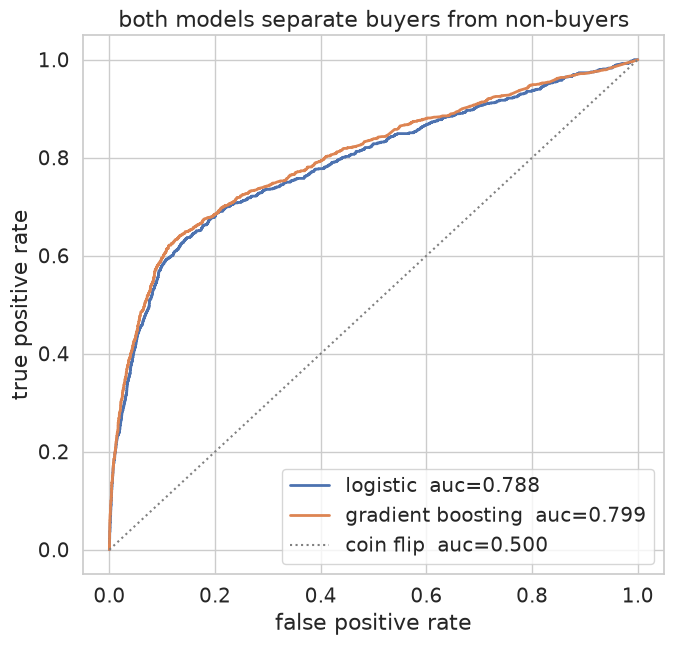

In [15]:
#roc curves
from sklearn.metrics import roc_curve
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(7.5, 7))
for name, pr in prob.items():
    xp, yp, _ = roc_curve(y_test, pr)
    p = ax.plot(xp, yp, linewidth=2, label=name + '  auc=' + str(round(roc_auc_score(y_test, pr), 3)))
p = ax.plot([0, 1], [0, 1], linestyle=':', color='grey', linewidth=1.5, label='coin flip  auc=0.500')
p = ax.set_title('both models separate buyers from non-buyers')
p = ax.set_xlabel('false positive rate')
p = ax.set_ylabel('true positive rate')
p = ax.legend(loc='lower right')

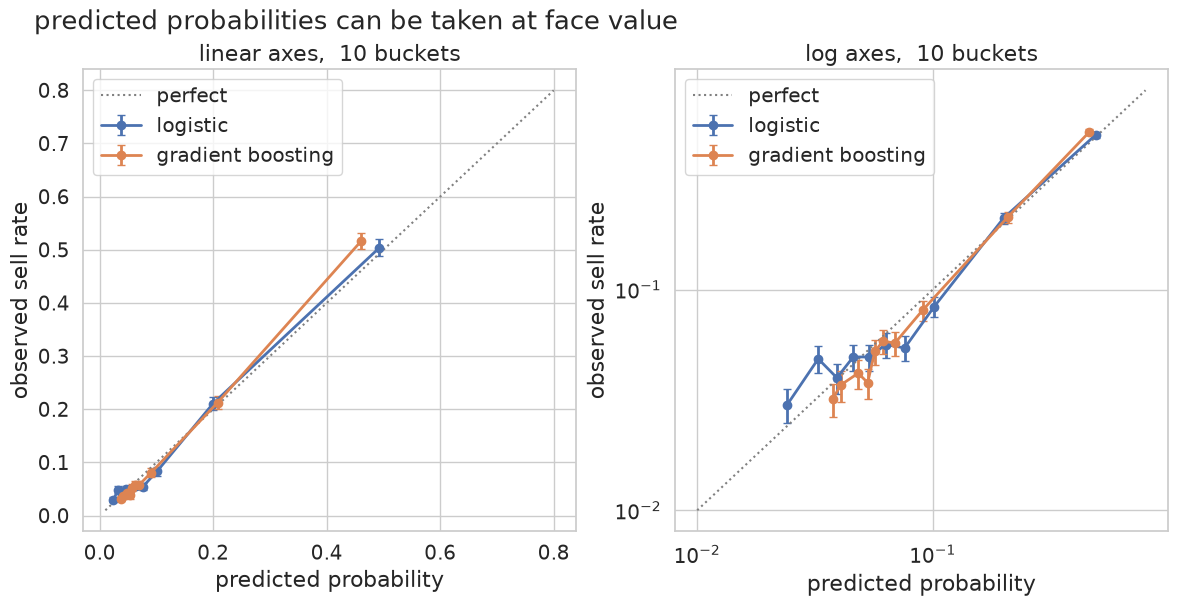

In [16]:
#calibrate the models: bucket the test customers into calib_bins having similar predicted
#probability, then check for instance that the 30% group really does buy about 30% of the time.
calib_bins = 10       #buckets in the calibration plot. more bins = finer detail more noise
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for name, pr in prob.items():
    d = pd.DataFrame({'y': y_test.values, 'p': pr})
    d['bin'] = pd.qcut(d.p.rank(method='first'), calib_bins, labels=False)
    g = d.groupby('bin').agg(n=('y', 'size'), predicted=('p', 'mean'), observed=('y', 'mean'))
    g['err'] = np.sqrt(g.observed*(1 - g.observed)/g.n)
    xp = g.predicted
    yp = g.observed
    for jdx in (0, 1):
        p = ax[jdx].errorbar(xp, yp, yerr=g.err, marker='o', markersize=6, linewidth=2,
                             capsize=3, label=name)
for jdx, scale in enumerate(['linear', 'log']):
    p = ax[jdx].plot([0.01, 0.8], [0.01, 0.8], linestyle=':', color='grey', linewidth=1.5,
                     label='perfect')
    p = ax[jdx].set_xscale(scale)
    p = ax[jdx].set_yscale(scale)
    p = ax[jdx].set_title(scale + ' axes,  ' + str(calib_bins) + ' buckets')
    p = ax[jdx].set_xlabel('predicted probability')
    p = ax[jdx].set_ylabel('observed sell rate')
    p = ax[jdx].legend(loc='upper left')
p = fig.suptitle('predicted probabilities can be taken at face value', x=0.09, ha='left')

## 5. does the model match reality?

In [17]:
#the test above showed the model is calibrated overall. this asks a harder and more useful
#question: is it right for every KIND of customer, or only on average? slice the test
#sample by the five features that drive the outcome and compare predicted vs actual.
#note this checks whether the model gets each group's rate right, which is what the
#targeting in notebook 3 relies on. the client's original column names are in brackets
df = test.copy()
df['predicted'] = prob['gradient boosting']
slices = {
    #prior_campaign_outcome* was the client's c8
    'previous campaign': df['prior_campaign_outcome*'].replace({'-1': 'none', 'no': 'failed', 'yes': 'sold'}),
    #age arrived named
    'age': pd.cut(df.age, [16, 25, 30, 40, 50, 60, 70, 100]),
    #employment arrived named
    'occupation': df.employment,
    #contacts_this_campaign* was n2
    'calls this campaign': pd.cut(df['contacts_this_campaign*'], [0, 1, 2, 3, 5, 10, 60]),
    #euribor_3m* was i4
    'interest rate': pd.cut(df['euribor_3m*'], [0, 1, 2, 3, 4, 5.1]),
}
compare = {}
for name, grouper in slices.items():
    g = df.groupby(grouper, observed=True).agg(
        n=('target', 'size'), actual=('target', 'mean'), predicted=('predicted', 'mean'))
    g = g[g.n >= 30]
    compare[name] = g
    print(f'{name:22s} worst gap = {(g.predicted - g.actual).abs().max():.3f}'
          f'   ({len(g)} groups, smallest n = {int(g.n.min()):,})')

previous campaign      worst gap = 0.086   (3 groups, smallest n = 311)
age                    worst gap = 0.103   (7 groups, smallest n = 108)
occupation             worst gap = 0.032   (12 groups, smallest n = 97)
calls this campaign    worst gap = 0.022   (6 groups, smallest n = 217)
interest rate          worst gap = 0.026   (3 groups, smallest n = 977)


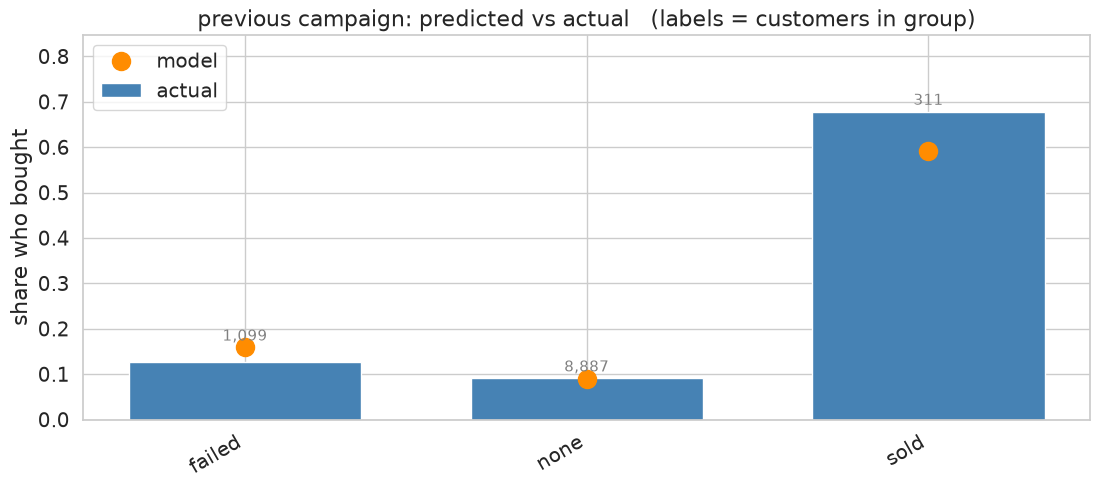

In [18]:
#prior_campaign_outcome* (the client's c8): customers we already sold to buy again
#at 68%, and the model knows it
g = compare['previous campaign']
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = np.arange(len(g))
p = ax.bar(xp, g.actual, color='steelblue', width=0.68, label='actual')
p = ax.plot(xp, g.predicted, linestyle='', marker='o', markersize=13,
            color='darkorange', label='model')
for jdx in range(len(g)):
    p = ax.text(jdx, max(g.actual.iloc[jdx], g.predicted.iloc[jdx]) + 0.015,
                format(int(g.n.iloc[jdx]), ','), ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in g.index], rotation=30, ha='right')
p = ax.set_ylim(0, max(g.actual.max(), g.predicted.max())*1.25)
p = ax.set_title('previous campaign: predicted vs actual   (labels = customers in group)')
p = ax.set_ylabel('share who bought')
p = ax.legend(loc='upper left')

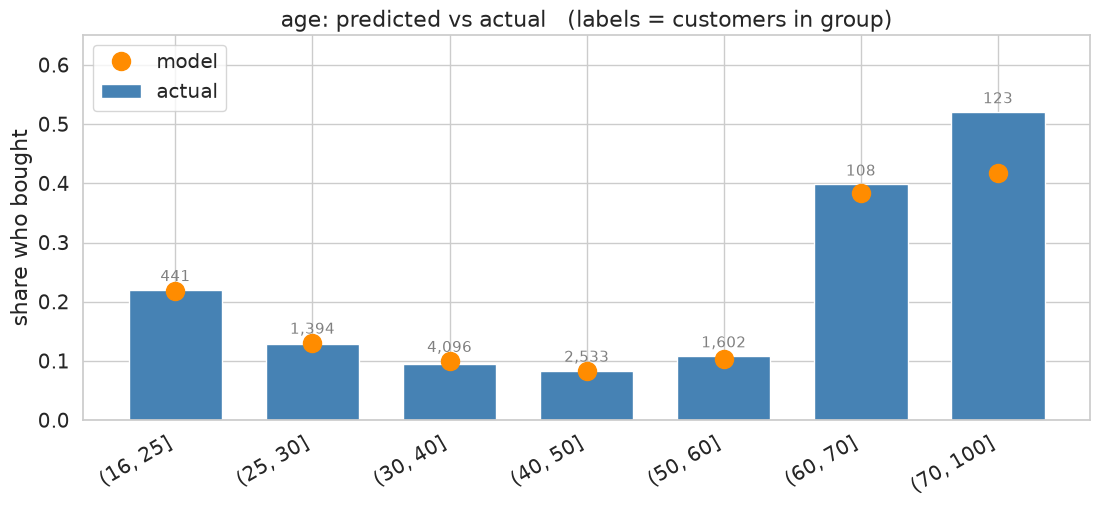

In [19]:
#age: the U-shape from notebook 1, tracked across all seven buckets
g = compare['age']
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = np.arange(len(g))
p = ax.bar(xp, g.actual, color='steelblue', width=0.68, label='actual')
p = ax.plot(xp, g.predicted, linestyle='', marker='o', markersize=13,
            color='darkorange', label='model')
for jdx in range(len(g)):
    p = ax.text(jdx, max(g.actual.iloc[jdx], g.predicted.iloc[jdx]) + 0.015,
                format(int(g.n.iloc[jdx]), ','), ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in g.index], rotation=30, ha='right')
p = ax.set_ylim(0, max(g.actual.max(), g.predicted.max())*1.25)
p = ax.set_title('age: predicted vs actual   (labels = customers in group)')
p = ax.set_ylabel('share who bought')
p = ax.legend(loc='upper left')

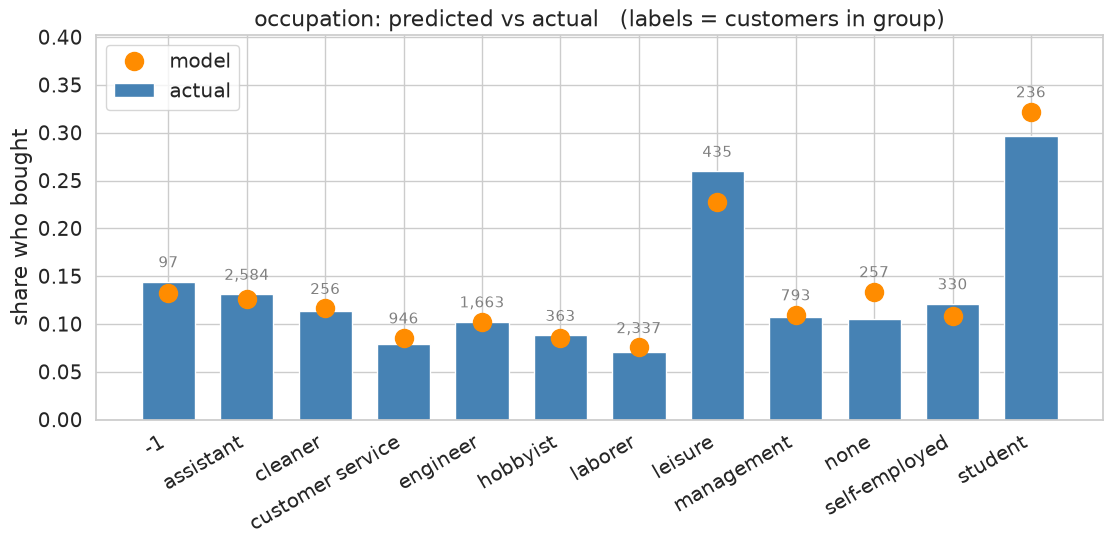

In [20]:
#employment: twelve occupations and the model is never off by more than 3.2 points
g = compare['occupation']
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = np.arange(len(g))
p = ax.bar(xp, g.actual, color='steelblue', width=0.68, label='actual')
p = ax.plot(xp, g.predicted, linestyle='', marker='o', markersize=13,
            color='darkorange', label='model')
for jdx in range(len(g)):
    p = ax.text(jdx, max(g.actual.iloc[jdx], g.predicted.iloc[jdx]) + 0.015,
                format(int(g.n.iloc[jdx]), ','), ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in g.index], rotation=30, ha='right')
p = ax.set_ylim(0, max(g.actual.max(), g.predicted.max())*1.25)
p = ax.set_title('occupation: predicted vs actual   (labels = customers in group)')
p = ax.set_ylabel('share who bought')
p = ax.legend(loc='upper left')

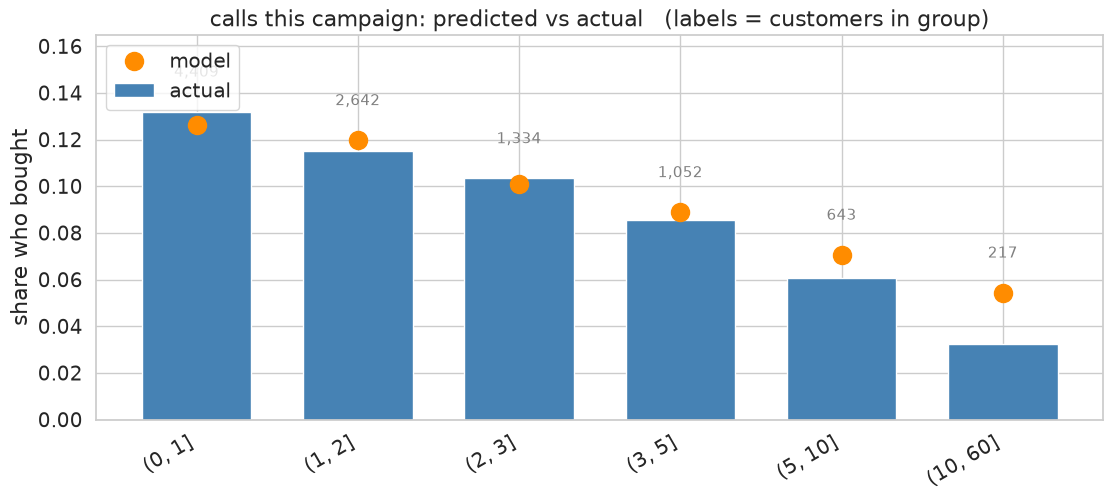

In [21]:
#contacts_this_campaign* (the client's n2): contact fatigue, predicted and actual
#falling together call after call
g = compare['calls this campaign']
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = np.arange(len(g))
p = ax.bar(xp, g.actual, color='steelblue', width=0.68, label='actual')
p = ax.plot(xp, g.predicted, linestyle='', marker='o', markersize=13,
            color='darkorange', label='model')
for jdx in range(len(g)):
    p = ax.text(jdx, max(g.actual.iloc[jdx], g.predicted.iloc[jdx]) + 0.015,
                format(int(g.n.iloc[jdx]), ','), ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in g.index], rotation=30, ha='right')
p = ax.set_ylim(0, max(g.actual.max(), g.predicted.max())*1.25)
p = ax.set_title('calls this campaign: predicted vs actual   (labels = customers in group)')
p = ax.set_ylabel('share who bought')
p = ax.legend(loc='upper left')

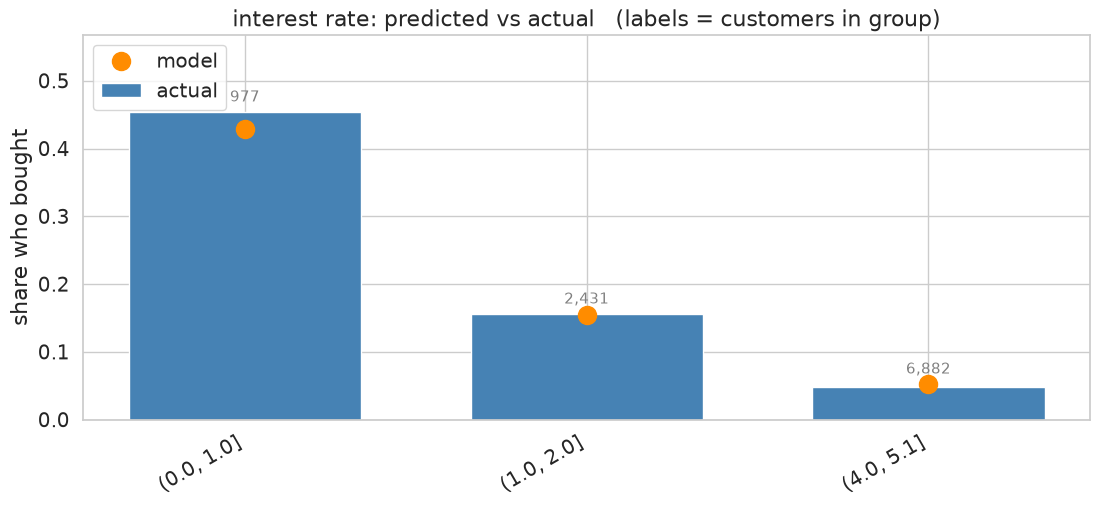

In [22]:
#euribor_3m* (the client's i4): the biggest driver in the data, and the model
#handles every rate environment
g = compare['interest rate']
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = np.arange(len(g))
p = ax.bar(xp, g.actual, color='steelblue', width=0.68, label='actual')
p = ax.plot(xp, g.predicted, linestyle='', marker='o', markersize=13,
            color='darkorange', label='model')
for jdx in range(len(g)):
    p = ax.text(jdx, max(g.actual.iloc[jdx], g.predicted.iloc[jdx]) + 0.015,
                format(int(g.n.iloc[jdx]), ','), ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in g.index], rotation=30, ha='right')
p = ax.set_ylim(0, max(g.actual.max(), g.predicted.max())*1.25)
p = ax.set_title('interest rate: predicted vs actual   (labels = customers in group)')
p = ax.set_ylabel('share who bought')
p = ax.legend(loc='upper left')

the dots sit on the bars throughout. where they do not quite, the model is pulled toward the average: it under-predicts the best groups (sold before, 70+) and over-predicts the worst (10+ calls), all by under two standard errors and all in the smallest groups. that is regularisation doing its job, and it errs conservatively for targeting.

noise floor =  7e-05  roc_auc
at or below it:  ['never_contacted_before', 'has_personal_loan*', 'is_repeat_contact']


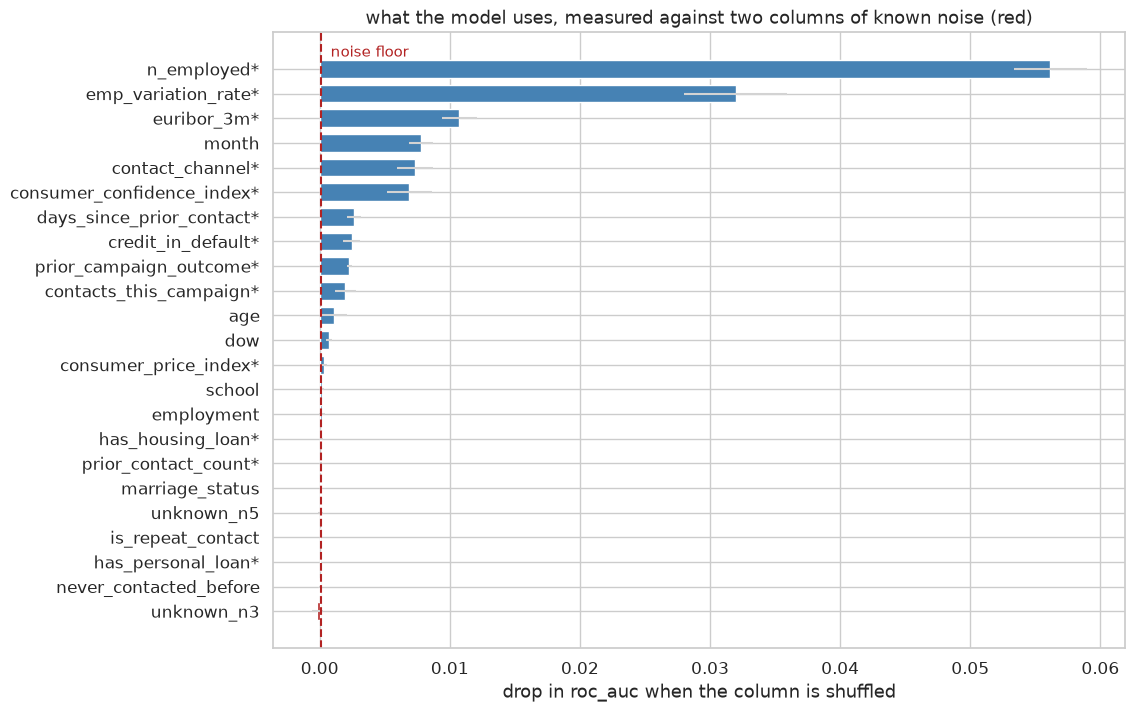

In [23]:
#which columns is the model actually using? shuffle one column at a time and see how far
#roc_auc falls. unknown_n3 and unknown_n5 are the random columns we kept from notebook 1,
#so whatever they score is what pure noise looks like and anything at or below that line
#has not earned its place. note this measures each column's UNIQUE contribution, so a
#feature whose signal is also carried by a neighbour scores lower than it deserves
from sklearn.inspection import permutation_importance
noise_cols = ['unknown_n3', 'unknown_n5']
r = permutation_importance(tuned['gradient boosting'].best_estimator_, x_test, y_test,
                           scoring='roc_auc', n_repeats=5,
                           random_state=rn_seed, n_jobs=-1)
imp = pd.DataFrame({'feature': x_cols, 'drop': r.importances_mean, 'sd': r.importances_std}
                   ).sort_values('drop').reset_index(drop=True)
floor = imp[imp.feature.isin(noise_cols)]['drop'].max()
print('noise floor = ', round(floor, 5), ' roc_auc')
print('at or below it: ', list(imp[(imp['drop'] <= floor) & (~imp.feature.isin(noise_cols))].feature))

sns.set(font_scale=1.1, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
colors = ['firebrick' if f in noise_cols else ('grey' if d <= floor else 'steelblue')
          for f, d in zip(imp.feature, imp['drop'])]
p = ax.barh(imp.feature, imp['drop'], xerr=imp.sd, color=colors, height=0.72,
            error_kw={'ecolor': 'lightgrey'})
p = ax.axvline(floor, color='firebrick', linestyle='--', linewidth=1.5)
p = ax.text(floor, len(imp) - 0.5, '  noise floor', color='firebrick', fontsize=11)
p = ax.set_title('what the model uses, measured against two columns of known noise (red)')
p = ax.set_xlabel('drop in roc_auc when the column is shuffled')

In [24]:
#save both fitted pipelines for notebook 3. joblib stores the whole pipeline, encoder and
#scaler included, so scoring a new customer file is one predict_proba call and the
#preprocessing cannot drift out of step with the model
import joblib, os
models = {'logistic': tuned['logistic'].best_estimator_,
          'gradient boosting': tuned['gradient boosting'].best_estimator_}
joblib.dump(models, model_file)

#read it straight back and confirm it predicts identically
check = joblib.load(model_file)
print('saved ', model_file, ' (', round(os.path.getsize(model_file)/1e6, 2), 'MB )')
for name in models:
    same = np.allclose(check[name].predict_proba(x_test)[:, 1], tuned_prob[name])
    print('  ', name, ' reloads and predicts identically = ', same)

saved  models.joblib  ( 0.21 MB )
   logistic  reloads and predicts identically =  True
   gradient boosting  reloads and predicts identically =  True


## what we found

| finding | what it means |
|---|---|
| both models land at roc_auc 0.79-0.80 | the two families agree closely |
| tuning moved auc by less than 0.005 | inside the noise of a different train/test seed, so the data is the ceiling, not the algorithm |
| gradient boosting leads logistic by ~0.01 roc_auc | small enough that interpretability, not accuracy, should pick the winner |
| both models are well calibrated | so the models can be used to estimate ROI |


In [25]:
#done
print('execution time (min) = ', round((tm.time() - clock_start)/60.0, 2))

execution time (min) =  0.69
